In [1]:
import pandas as pd

In [2]:
teen_dt=pd.read_csv("Teen_Mental_Health_Dataset.cs")
teen_dt

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,17,male,3.7,Other,6.1,1.8,2.82,0.4,low,5,5,medium
2496,17,female,7.4,TikTok,4.0,2.6,2.32,1.4,medium,9,9,medium
2497,15,female,6.3,Both,5.0,1.6,2.35,1.2,high,9,10,medium
2498,17,female,4.5,TikTok,6.7,1.9,2.90,0.4,medium,7,7,medium


**Checking the structure of the dataframe**

In [4]:
teen_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


**Checking whether any column is associated with null value**

In [6]:
teen_dt.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
depression_risk             0
dtype: int64

**Describe method gives the total quantitaive stats related with the numerical column**

In [8]:
teen_dt.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

**We see the patterns or a simple layout of the categorical datas**

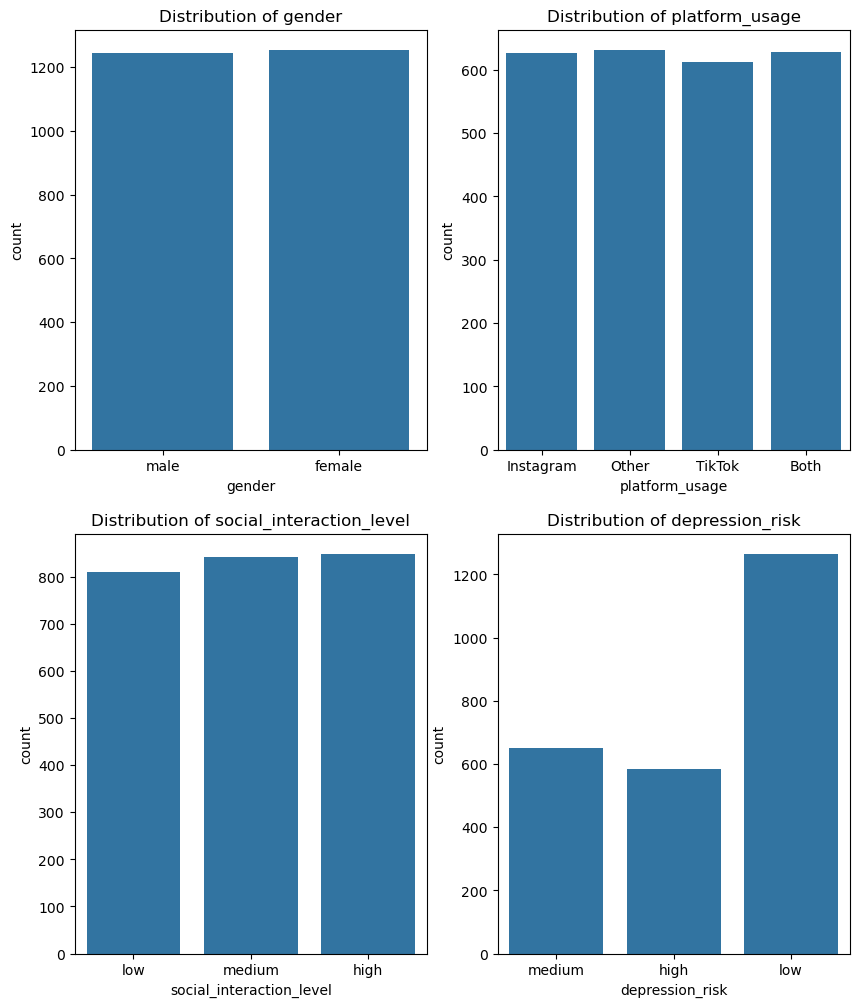

In [11]:

cat_cols=["gender","platform_usage","social_interaction_level","depression_risk"]
plt.figure(figsize=(10,12))
for i,col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(data=teen_dt,x=col)
    plt.title(f'Distribution of {col}')

plt.show()
    

**Now ,lets see for numerical datas**

In [13]:
col=teen_dt.columns
col


Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'depression_risk'],
      dtype='object')

In [14]:
l1=[]
for i in col:
    if(teen_dt[i].dtype != "object"):
        l1.append(i)
l1

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'stress_level',
 'anxiety_level']

In [15]:
teen_dt.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'depression_risk'],
      dtype='object')

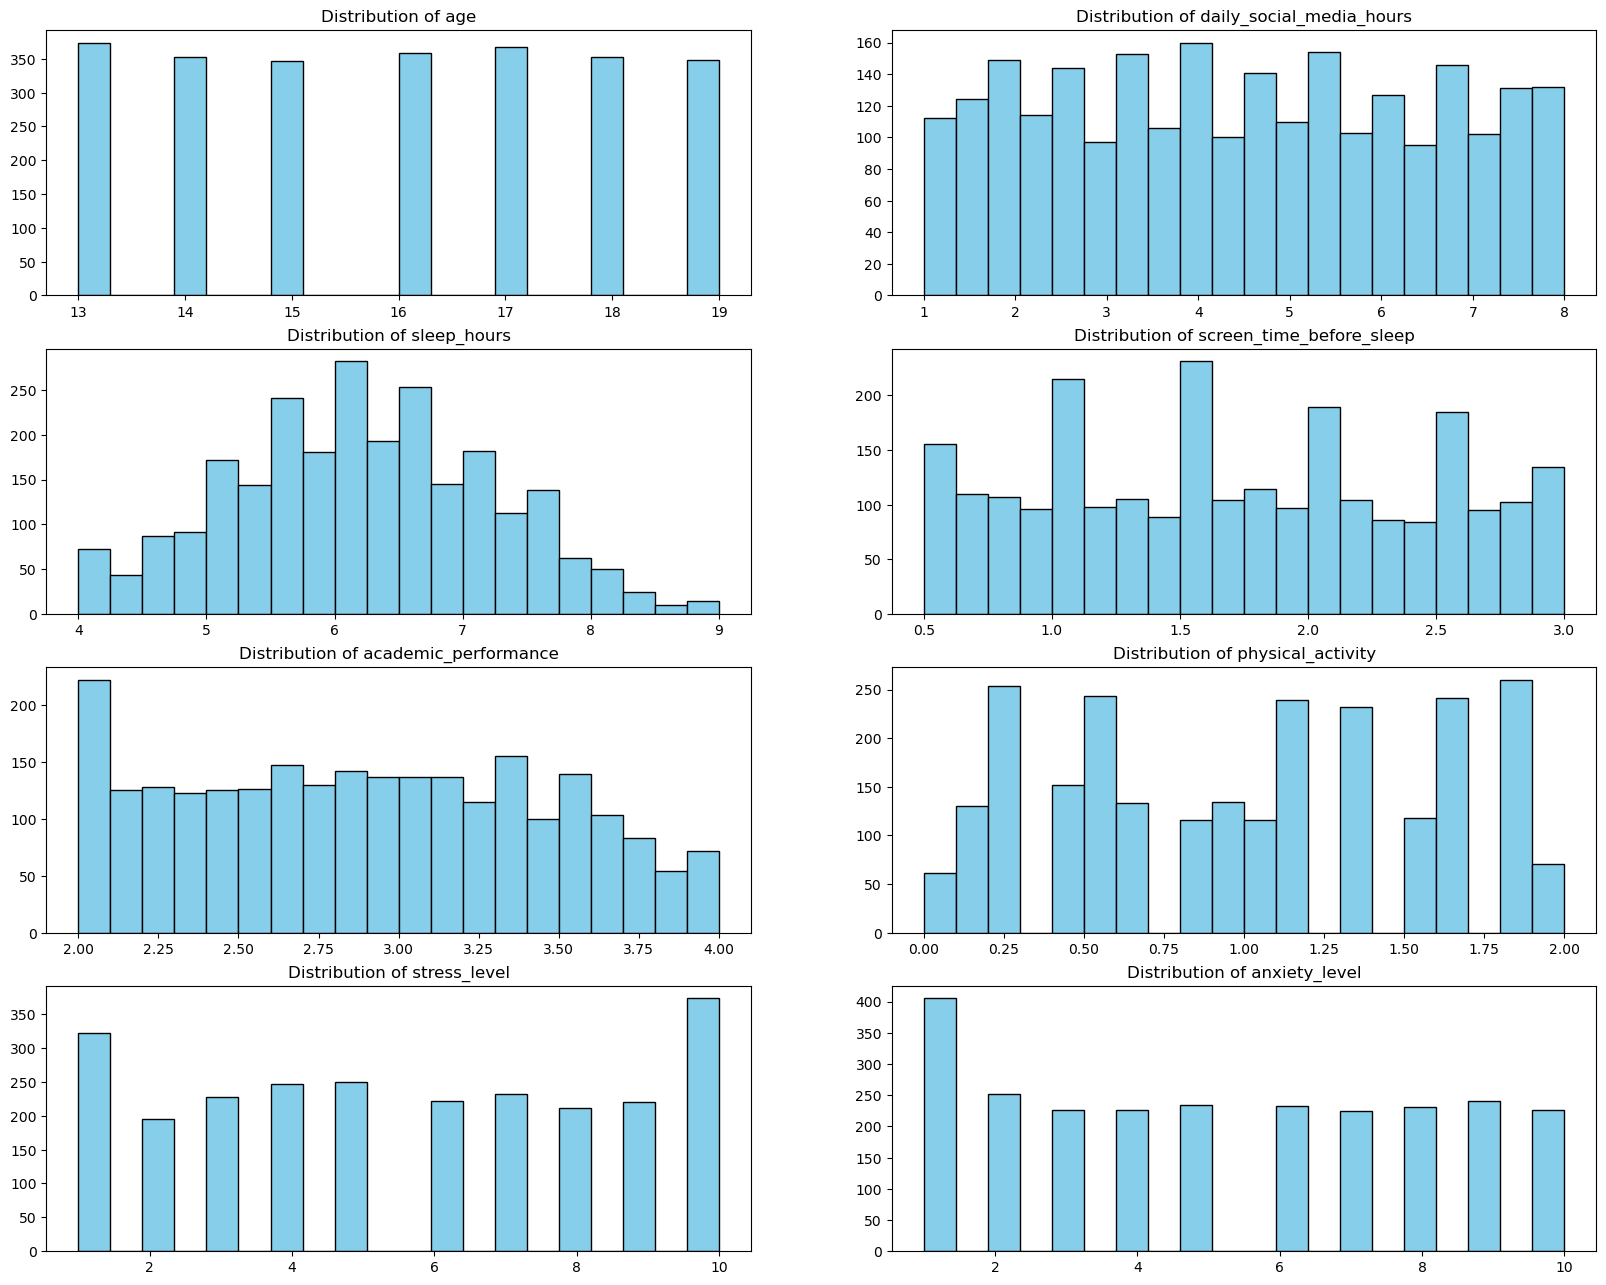

In [16]:
plt.figure(figsize=(20,20))
for i,j in enumerate(l1):
    plt.subplot(5,2,i+1)
    plt.hist(teen_dt[j],bins=20,color='skyblue',edgecolor='black')
    plt.title(f'Distribution of {j}')
    
plt.show()

**Label Encoding for ordinal data.i.e.data with order/One hot encoder for nominal data.i.e without order**

**Converting categorical data into numerical .So,that there will be ease in machine learning**

In [19]:
cat_cols

['gender', 'platform_usage', 'social_interaction_level', 'depression_risk']

In [20]:
risk_map={"low":0,"medium":1,"high":2}

In [21]:
risk_map={"low":0,"medium":1,"high":2}
teen_dt["num_social_interactlevel"]=teen_dt["social_interaction_level"].map(risk_map)
teen_dt["num_depression_risk"]=teen_dt["depression_risk"].map(risk_map)
teen_dt

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,num_social_interactlevel,num_depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0,1
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1,2
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2,0
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,1,1
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,17,male,3.7,Other,6.1,1.8,2.82,0.4,low,5,5,medium,0,1
2496,17,female,7.4,TikTok,4.0,2.6,2.32,1.4,medium,9,9,medium,1,1
2497,15,female,6.3,Both,5.0,1.6,2.35,1.2,high,9,10,medium,2,1
2498,17,female,4.5,TikTok,6.7,1.9,2.90,0.4,medium,7,7,medium,1,1


**One hot encoder**

In [23]:
teen_dt=pd.get_dummies(teen_dt,columns=["gender","platform_usage"])
teen_dt

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,num_social_interactlevel,num_depression_risk,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_Other,platform_usage_TikTok
0,19,3.8,6.5,1.7,2.77,1.2,low,6,6,medium,0,1,False,True,False,True,False,False
1,16,6.5,5.8,0.6,2.57,0.2,medium,9,7,high,1,2,False,True,False,False,True,False
2,17,2.9,7.0,1.2,3.04,1.7,high,3,2,low,2,0,True,False,False,False,True,False
3,19,7.9,5.0,1.6,2.21,1.2,medium,10,8,medium,1,1,True,False,False,False,False,True
4,15,1.2,8.8,0.9,3.61,1.9,high,1,2,low,2,0,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,17,3.7,6.1,1.8,2.82,0.4,low,5,5,medium,0,1,False,True,False,False,True,False
2496,17,7.4,4.0,2.6,2.32,1.4,medium,9,9,medium,1,1,True,False,False,False,False,True
2497,15,6.3,5.0,1.6,2.35,1.2,high,9,10,medium,2,1,True,False,True,False,False,False
2498,17,4.5,6.7,1.9,2.90,0.4,medium,7,7,medium,1,1,True,False,False,False,False,True


**Using np.where();I can use it previously but classification and use of encoder will provide insights**

**You can use .astype() instead of np .where for higher readabilty**

In [26]:
cols = ["gender_male","gender_female","platform_usage_Both", "platform_usage_Instagram", "platform_usage_Other", "platform_usage_TikTok"]
teen_dt[cols]=teen_dt[cols].astype(int)

**What astype does is converts true to 1,and false to 0**

In [28]:
teen_dt

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,num_social_interactlevel,num_depression_risk,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_Other,platform_usage_TikTok
0,19,3.8,6.5,1.7,2.77,1.2,low,6,6,medium,0,1,0,1,0,1,0,0
1,16,6.5,5.8,0.6,2.57,0.2,medium,9,7,high,1,2,0,1,0,0,1,0
2,17,2.9,7.0,1.2,3.04,1.7,high,3,2,low,2,0,1,0,0,0,1,0
3,19,7.9,5.0,1.6,2.21,1.2,medium,10,8,medium,1,1,1,0,0,0,0,1
4,15,1.2,8.8,0.9,3.61,1.9,high,1,2,low,2,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,17,3.7,6.1,1.8,2.82,0.4,low,5,5,medium,0,1,0,1,0,0,1,0
2496,17,7.4,4.0,2.6,2.32,1.4,medium,9,9,medium,1,1,1,0,0,0,0,1
2497,15,6.3,5.0,1.6,2.35,1.2,high,9,10,medium,2,1,1,0,1,0,0,0
2498,17,4.5,6.7,1.9,2.90,0.4,medium,7,7,medium,1,1,1,0,0,0,0,1


**Lets see its Correlation**

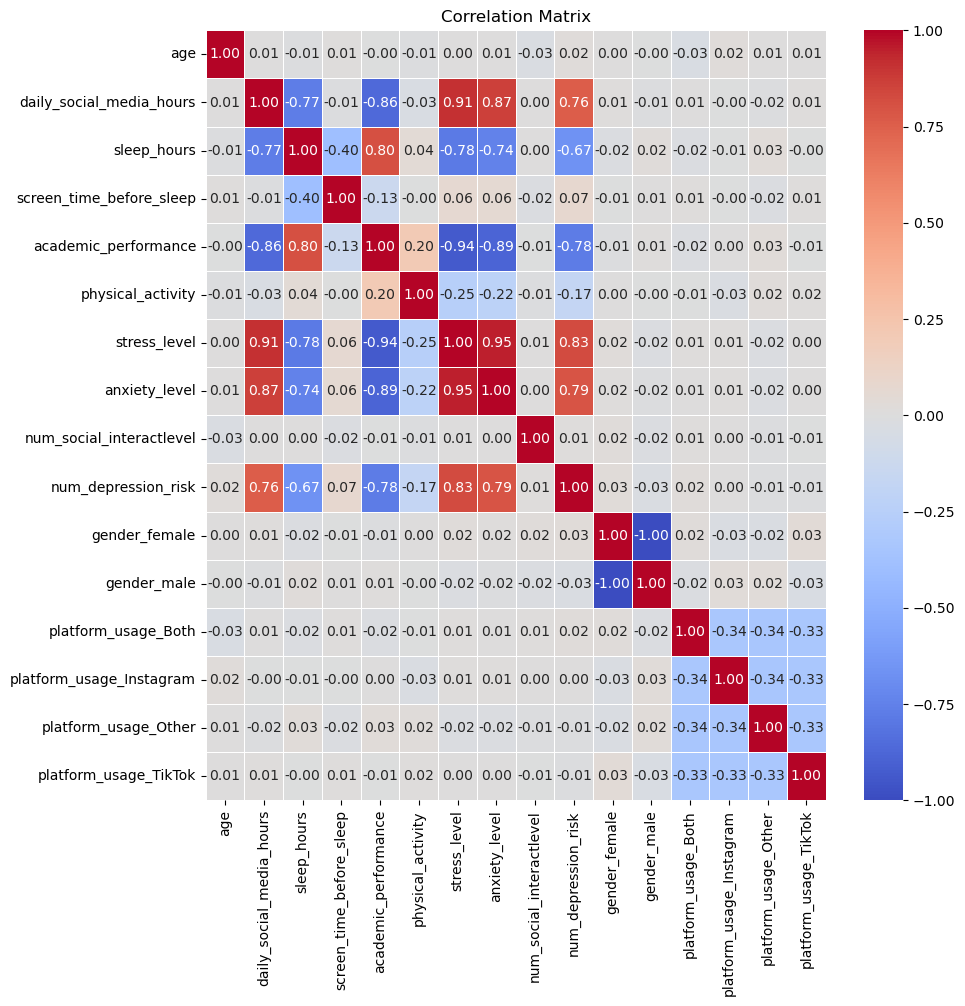

In [30]:
corr=teen_dt.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,fmt=".2f",cmap='coolwarm',linewidths=0.5,linecolor="white")
plt.title("Correlation Matrix")
plt.show()

**I will show a particular description of a instance of teen-dt**

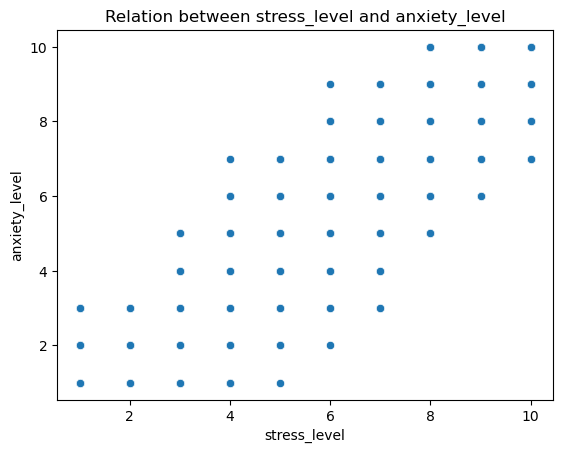

In [32]:
sns.scatterplot(teen_dt,x="stress_level",y="anxiety_level")
plt.title("Relation between stress_level and anxiety_level")
plt.show()

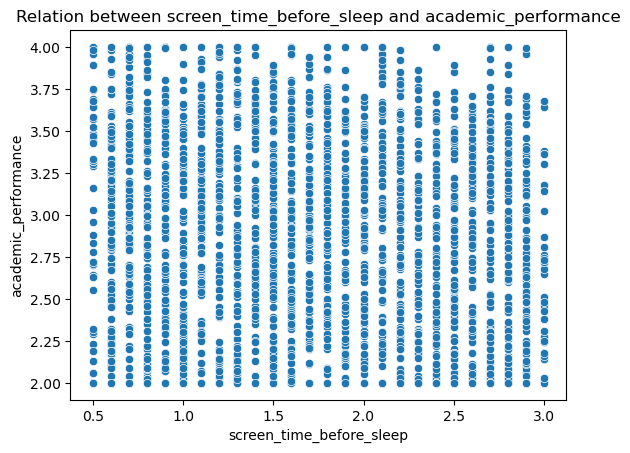

In [59]:
sns.scatterplot(teen_dt,x="screen_time_before_sleep",y="academic_performance")
plt.title("Relation between screen_time_before_sleep and academic_performance")
plt.show()

**We can infer that there is little  to no relation between these two aspects**

In [66]:
from sklearn.model_selection import train_test_split

**Let me copy the original dataset .So,the changes doesnot reflect on the initial one**

In [93]:
df_encoded=teen_dt.copy()

In [101]:
# 1. Define Target and Features clearly
y = df_encoded["num_depression_risk"]
X = df_encoded.drop(["depression_risk", "num_depression_risk","social_interaction_level"], axis=1)


In [105]:
# 2. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


RandomForestClassifier()

In [109]:
# 3. Initialize and Fit
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [115]:
print(classification_report(y_test,y_pred))

Accuracy: 0.756
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       256
           1       0.55      0.43      0.49       132
           2       0.68      0.92      0.78       112

    accuracy                           0.76       500
   macro avg       0.71      0.73      0.71       500
weighted avg       0.75      0.76      0.75       500



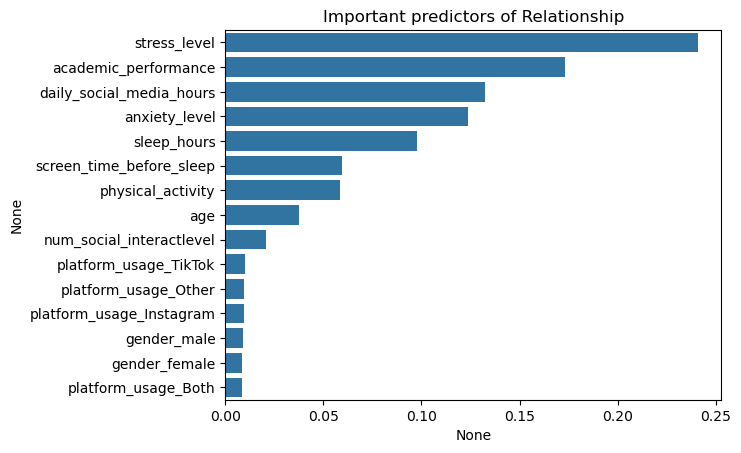

In [143]:
relation=model.feature_importances_
field=X.columns
data=pd.Series(relation,index=field).sort_values(ascending=False)
sns.barplot(x=data,y=data.index,)
plt.title("Important predictors of Relationship")
plt.show()